In [38]:
from pathlib import Path
import pandas as pd
from IPython.display import display

DATA_PATH = Path('horse_colic.csv')
df = pd.read_csv(DATA_PATH)
print(f'{len(df)} строк, {df.shape[1]} полей, {df.isna().sum().sum()} пропусков')
display(df.head())

368 строк, 28 полей, 1927 пропусков


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,2,11300,0,0,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2,2208,0,0,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,2,0,0,0,1
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,1,2208,0,0,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,2,4300,0,0,2


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_missing_upset(data, top_n=25, title='Horse Colic', figsize=(10, 8.6)):
    """Точные сочетания NaN: признаки по X, сочетания по Y.

    Возвращает figure, словарь axes и таблицу показанных сочетаний.
    Поля без пропусков скрыты. Номера строк таблицы идут сверху вниз.
    """
    if data.empty or not data.columns.is_unique:
        raise ValueError('Нужны непустые данные с уникальными названиями столбцов.')
    if not isinstance(top_n, int) or top_n < 1:
        raise ValueError('top_n должен быть положительным целым числом.')
    counts = data.isna().sum().sort_values(ascending=False, kind='stable')
    counts = counts[counts > 0]
    if counts.empty:
        raise ValueError('В данных нет пропусков.')
    missing = data[counts.index].isna()
    complete = int((~missing.any(axis=1)).sum())
    # sort=False и стабильная сортировка сохраняют порядок первого появления
    # при одинаковом размере сочетаний.
    patterns = (missing.loc[missing.any(axis=1)]
                .groupby(list(counts.index), sort=False).size()
                .sort_values(ascending=False, kind='stable'))
    shown = patterns.head(top_n)
    membership = np.array(shown.index.tolist(), dtype=bool).reshape(-1, len(counts))
    sizes = shown.to_numpy()
    n, k = membership.shape

    fig = plt.figure(figsize=figsize, dpi=90, facecolor='white')
    grid = fig.add_gridspec(
    2, 2,
    width_ratios=[k, 12],
    height_ratios=[7, n],
    wspace=0.03,
    hspace=0.03
    )
    top = fig.add_subplot(grid[0, 0])
    matrix = fig.add_subplot(grid[1, 0], sharex=top)
    right = fig.add_subplot(grid[1, 1], sharey=matrix)
    blue, dark, pale = '#3779AD', '#253B4C', '#E8EDF1'
    x, y = np.arange(k), np.arange(n)

    bars = top.bar(x, counts.values, width=0.62, color=blue, zorder=3)
    top.bar_label(bars, padding=3, fontsize=9)
    top.set_ylim(0, counts.max() * 1.12)
    top.set_ylabel('Число пропусков', fontsize=11)
    top.set_xticks(x, counts.index, rotation=90, ha='center', fontsize=10)
    top.xaxis.tick_top()
    top.tick_params(axis='x', length=0, pad=13)
    top.yaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
    top.grid(axis='y', color='#EEF0F2', zorder=0)

    for row in range(n):
        if row % 2 == 0:
            for ax in (matrix, right):
                ax.axhspan(row - 0.5, row + 0.5, color='#F2F5F8', zorder=0)
    matrix.scatter(np.tile(x, n), np.repeat(y, k), s=68, color=pale,
                   edgecolors='none', zorder=2)
    for row, signature in enumerate(membership):
        active = x[signature]
        if len(active) > 1:
            matrix.plot([active[0], active[-1]], [row, row], color=dark,
                        linewidth=1.9, zorder=3)
        matrix.scatter(active, np.full(len(active), row), s=94, color=dark,
                       edgecolors='none', zorder=4)
    matrix.set_xlim(-0.6, k - 0.4)
    matrix.set_ylim(n - 0.5, -0.5)
    matrix.tick_params(axis='x', bottom=False, labelbottom=False)
    matrix.set_yticks([])
    matrix.set_xlabel('Тёмная точка — значение отсутствует (NaN)', fontsize=11)

    bars = right.barh(y, sizes, height=0.62, color=blue, zorder=3)
    right.bar_label(bars, padding=3, fontsize=9)
    right.set_xlim(0, max(sizes) * 2.5)
    right.set_xlabel('Строк с точным сочетанием NaN', fontsize=10, loc='right')
    right.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
    right.grid(axis='x', color='#E8EDF1', zorder=0)
    right.tick_params(axis='y', left=False, labelleft=False)
    for ax in (top, matrix, right):
        ax.spines[:].set_visible(False)
        ax.tick_params(colors='#333333', labelsize=7)

    fig.subplots_adjust(
    left=0.065,
    right=0.975,
    bottom=0.065,
    top=0.80
    )
    table = pd.DataFrame(membership, columns=counts.index)
    table.insert(0, 'count', sizes)
    table.index = pd.RangeIndex(1, n + 1, name='intersection_id')
    return fig, {'totals': top, 'matrix': matrix, 'sizes': right}, table


def filter_by_nan_intersection(data, missing, exact=True, columns=None):
    """exact=True требует заполненности остальных полей выбранной области."""
    missing = list(missing)
    columns = list(data.columns if columns is None else columns)
    unknown = (set(missing) | set(columns)) - set(data.columns)
    if unknown:
        raise KeyError(f'Нет столбцов: {unknown}')
    mask = data[missing].isna().all(axis=1)
    if exact:
        mask &= data[[c for c in columns if c not in missing]].notna().all(axis=1)
    return data.loc[mask].copy()


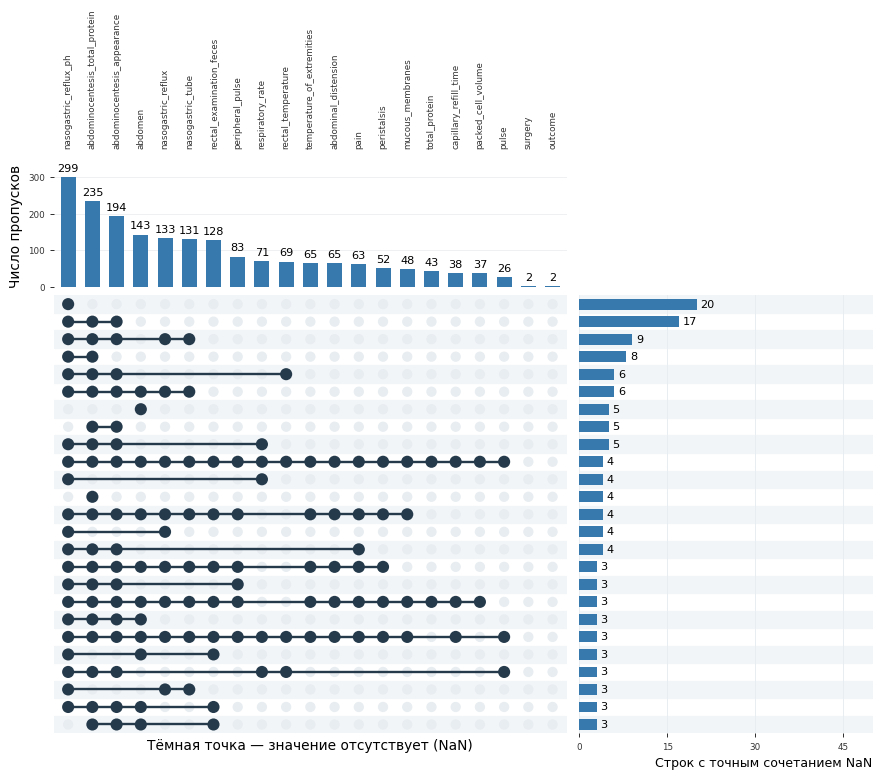

In [40]:
fig, axes, intersections = plot_missing_upset(df, top_n=25)
plt.show()

In [41]:
intersection_id = 1
row = intersections.loc[intersection_id]
missing_columns = [c for c in intersections.columns if c != 'count' and row[c]]
filtered_df = filter_by_nan_intersection(df, missing_columns, exact=True)
print('Поля с NaN:', missing_columns)
print('Строк:', len(filtered_df))
display(filtered_df)

Поля с NaN: ['nasogastric_reflux_ph']
Строк: 20


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
14,1.0,1,534917,38.2,76.0,28.0,3.0,1.0,1.0,1.0,...,46.0,81.0,1.0,2.0,1.0,1,2112,0,0,2
26,1.0,1,530526,38.3,72.0,30.0,4.0,3.0,3.0,2.0,...,43.0,7.0,2.0,3.9,1.0,1,3111,0,0,1
49,2.0,1,529642,37.2,84.0,48.0,3.0,3.0,5.0,2.0,...,73.0,5.5,2.0,4.1,2.0,2,4300,0,0,1
88,2.0,1,529703,39.0,64.0,40.0,1.0,1.0,5.0,1.0,...,42.0,7.5,2.0,2.3,1.0,2,5000,0,0,1
99,2.0,1,530002,39.6,108.0,51.0,3.0,3.0,6.0,2.0,...,59.0,8.0,2.0,2.6,1.0,2,4300,0,0,1
123,1.0,1,530360,38.2,64.0,24.0,1.0,1.0,3.0,1.0,...,45.0,7.5,1.0,2.0,2.0,1,3205,0,0,1
156,2.0,1,528996,38.6,52.0,20.0,1.0,1.0,1.0,1.0,...,36.0,6.6,1.0,5.0,1.0,2,0,0,0,1
187,1.0,1,527365,38.4,80.0,30.0,4.0,3.0,1.0,1.0,...,32.0,6.1,3.0,4.3,1.0,1,7209,0,0,1
196,2.0,1,529628,38.5,60.0,20.0,1.0,1.0,5.0,2.0,...,63.0,7.5,2.0,2.3,3.0,2,300,0,0,1
211,1.0,1,529893,38.0,86.0,24.0,4.0,3.0,4.0,1.0,...,45.0,5.5,1.0,10.1,2.0,1,3111,0,0,1
